## RIMO LFI and HFI values

Link - https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/

In [1]:
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, repo_root)
os.environ["CMB_ML_DATA"] = "/bigdata/cmb_project/data/"
sys.path.append("/bigdata/aankit/lost_in_space/")
os.environ['XDG_CONFIG_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_config'
os.environ['XDG_CACHE_HOME'] = '/bigdata/cmb_project/xdg_home/xdg_cache'

from astropy.io import fits
import matplotlib.pyplot as plt

import numpy as np
import healpy as hp
from time import time
import matplotlib.pyplot as plt

import hydra
from hydra import compose, initialize

from cmbml.utils.planck_instrument import make_instrument
from cmbml_utils import PipeAccessor  # make sure to add ../lost_in_space to sys.path
from utils.show_maps import show_obs_logNxN

import pysm3
import pysm3.units as u




from astropy.config.paths import get_cache_dir
print("Astropy cache dir:", get_cache_dir()) 


Astropy cache dir: /bigdata/cmb_project/xdg_home/xdg_cache/astropy


In [2]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
initialize(version_base=None)
cfg = compose(config_name='config_sim', overrides=["+min_obs_beam=0"])  # Only used for the instrument
pa = PipeAccessor(cfg, "raw_in")
sim_det_info = pa.assets_in['deltabandpass'].read()
SIM_INSTRUMENT = make_instrument(cfg=cfg,
                                 det_info=sim_det_info)

In [3]:

filename_lfi = "/bigdata/aankit/rimo_files/LFI_RIMO_R3.31.fits"
filename_hfi = "/bigdata/aankit/rimo_files/HFI_RIMO_R3.00.fits"
hdul_lfi = fits.open(filename_lfi)
hdul_hfi = fits.open(filename_hfi)


In [4]:
print(hdul_lfi.info())

Filename: /bigdata/aankit/rimo_files/LFI_RIMO_R3.31.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   ()      
  1  CHANNEL_PARAMETERS    1 BinTableHDU     62   22R x 15C   [8A, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   
  2  FREQUENCY_MAP_PARAMETERS    1 BinTableHDU     48   3R x 10C   [3A, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E]   
  3  BANDPASS_030-28S    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  4  BANDPASS_030-28M    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  5  BANDPASS_030-27S    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  6  BANDPASS_030-27M    1 BinTableHDU     30   188R x 4C   [1D, 1D, 1E, 1A]   
  7  BANDPASS_044-26S    1 BinTableHDU     30   151R x 4C   [1D, 1D, 1E, 1A]   
  8  BANDPASS_044-26M    1 BinTableHDU     30   151R x 4C   [1D, 1D, 1E, 1A]   
  9  BANDPASS_044-25S    1 BinTableHDU     30   151R x 4C   [1D, 1D, 1E, 1A]   
 10  BANDPASS_044-25M    1 BinTab

In [5]:
print(hdul_hfi.info())


Filename: /bigdata/aankit/rimo_files/HFI_RIMO_R3.00.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  HFI_RIMO      1 PrimaryHDU      14   ()      
  1  MAP_PARAMS    1 BinTableHDU     50   6R x 10C   [3A, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   
  2  BANDPASS_F100    1 BinTableHDU     28   12297R x 3C   [1E, 1E, 1A]   
  3  BANDPASS_F100    1 BinTableHDU     28   12297R x 3C   [1E, 1E, 1A]   
  4  BANDPASS_F143    1 BinTableHDU     28   12602R x 3C   [1E, 1E, 1A]   
  5  BANDPASS_F217    1 BinTableHDU     28   12600R x 3C   [1E, 1E, 1A]   
  6  BANDPASS_F353    1 BinTableHDU     28   12930R x 3C   [1E, 1E, 1A]   
  7  BANDPASS_F545    1 BinTableHDU     28   13938R x 3C   [1E, 1E, 1A]   
  8  BANDPASS_F857    1 BinTableHDU     28   16819R x 3C   [1E, 1E, 1A]   
  9  BANDPASS_PSB353    1 BinTableHDU     28   12930R x 3C   [1E, 1E, 1A]   
None


In [6]:
bandpass_lfi = hdul_lfi['BANDPASS_030']
bandpass_hfi = hdul_hfi['BANDPASS_F857']
print(bandpass_lfi.columns)
print(bandpass_hfi.columns)

ColDefs(
    name = 'WAVENUMBER'; format = '1D'; unit = 'GHz'
    name = 'TRANSMISSION'; format = '1D'; unit = 'n/a'
    name = 'UNCERTAINITY'; format = '1E'; unit = 'n/a'
    name = 'FLAG'; format = '1A'; unit = 'n/a'; dim = '(1,1)'
)
ColDefs(
    name = 'WAVENUMBER'; format = '1E'; unit = '1/cm'
    name = 'TRANSMISSION'; format = '1E'; unit = 'n/a'
    name = 'FLAG'; format = '1A'; dim = '(1,1)'
)


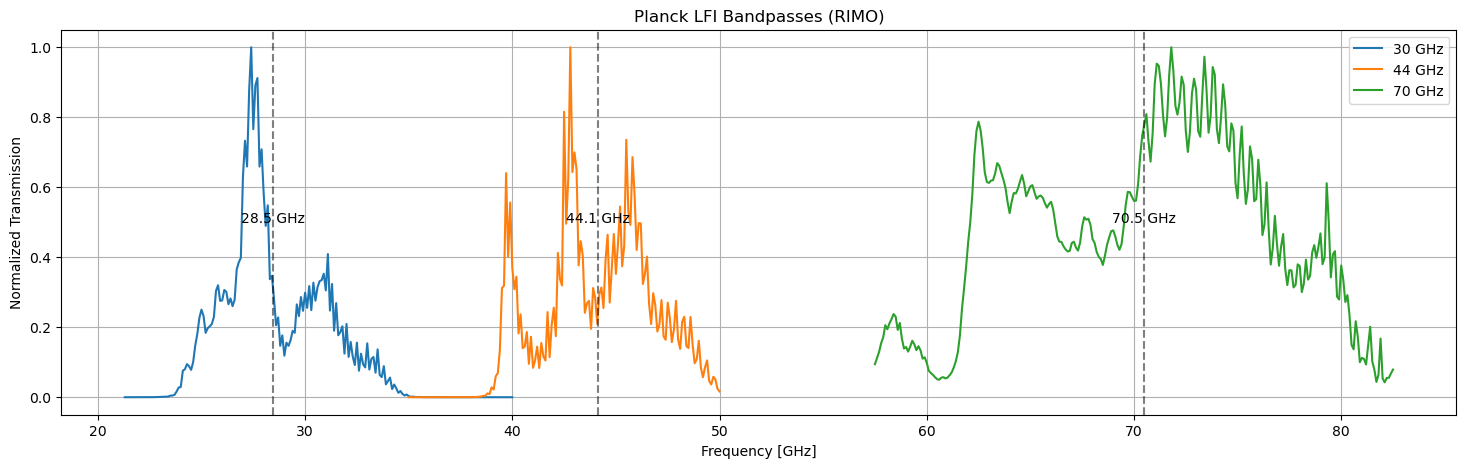

In [7]:


# Pick the bandpasses you care about
bandpasses = ["BANDPASS_030", "BANDPASS_044", "BANDPASS_070"]

plt.figure(figsize=(18,5))

for bp in bandpasses:
    hdu = hdul_lfi[bp]

    wn = hdu.data['WAVENUMBER'] * (1/u.cm)
    weights = hdu.data['TRANSMISSION'].astype(float)
    weights /= np.max(weights)   
    freq_eff = np.sum(wn * weights) / np.sum(weights)
    
    plt.plot(wn, weights, label=bp.replace("BANDPASS_0", "") + " GHz")
    plt.axvline(freq_eff.value, color='k', linestyle='--', alpha=0.5)
    plt.text(freq_eff.value, 0.5, f"{freq_eff.value:.1f} GHz", ha='center')
plt.xlabel("Frequency [GHz]")
plt.ylabel("Normalized Transmission")
plt.title("Planck LFI Bandpasses (RIMO)")
plt.legend()
plt.grid(True)
plt.show()


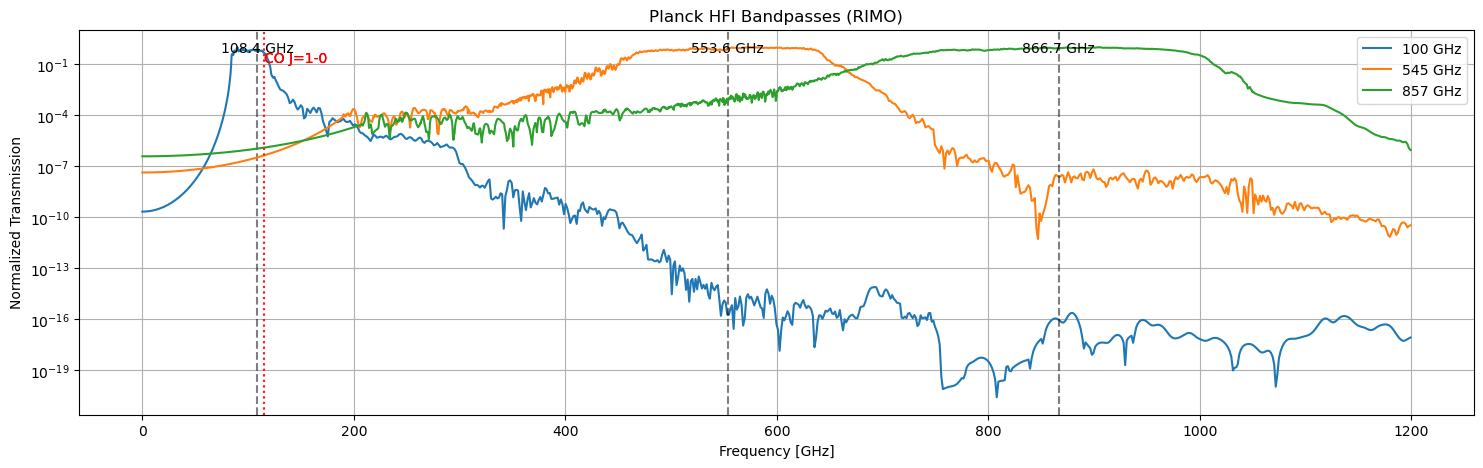

In [52]:
bandpasses = ["BANDPASS_F100", "BANDPASS_F545", "BANDPASS_F857"]

plt.figure(figsize=(18,5))

for bp in bandpasses:
    hdu = hdul_hfi[bp]

    # converting wavenumber to frequency
    wn = hdu.data['WAVENUMBER'] * (1/u.cm)
    freqs = wn.to(u.GHz, equivalencies=u.spectral())
    
    mask = freqs < 1200 *u.GHz #im doing this masking because the freq values are till 17987.547 GHz and the plot looks bad
    freqs = freqs[mask]
    weights = hdu.data['TRANSMISSION'].astype(float)[mask]
    # wn = hdu.data['WAVENUMBER'] * (1/u.cm)
    # weights = hdu.data['TRANSMISSION'].astype(float)
    weights /= np.max(weights)   # normalize peak to 1 for easier comparison
    freq_eff = np.sum(freqs * weights) / np.sum(weights)
    plt.plot(freqs, weights, label=bp.replace("BANDPASS_F", "") + " GHz")
    plt.axvline(freq_eff.value, color='k', linestyle='--', alpha=0.5)
    plt.text(freq_eff.value, 0.5, f"{freq_eff.value:.1f} GHz", ha='center')

    plt.axvline(115.271,color='r',linestyle=':',alpha=0.5)
    plt.text(115.271, 0.6, "CO J=1-0", color='r', va='top', ha='left')


plt.xlabel("Frequency [GHz]")
plt.ylabel("Normalized Transmission")
plt.title("Planck HFI Bandpasses (RIMO)")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()


In [53]:
def make_bandpass(center, width=1.0*u.GHz, n_points=50):
    freqs = center + np.linspace(-3, 3, n_points) * width
    weights = np.exp(-0.5 * ((freqs - center)/width)**2)
    weights /= np.sum(weights)
    return freqs, weights

## CO1 maps

In [ ]:
PRESET_STRINGS = ['co1']
CO_LINES = [115.3, 230.5, 345.8]  # GHz
NSIDE_SKY = 2048
NSIDE_OUT = 512

start = time()
sky = pysm3.Sky(nside=NSIDE_SKY, preset_strings=PRESET_STRINGS, output_unit=pysm3.units.uK_RJ)
print(f"Sky (co1) generation time: {time() - start:.2f}s" )

Sky (co1) generation time: 26.93s


In [82]:
def make_co_plots(freqs, weights, colors=['r', 'g', 'b']):
    plt.figure(figsize=(8,5))
    for i, lines in enumerate(CO_LINES):
        color = colors[i]
        plt.axvline(lines, linestyle='--', alpha=0.6, color=color)
        # Place text slightly to the right of the line, vertically centered (y=0.5)
        plt.text(lines + 5, 0.05, f"CO J={i+1}-{i} ({lines} GHz)", 
                va='center', ha='left', color=color, fontsize=9)
        plt.plot(freqs.value, weights)
        # plt.yscale('log')

### Using lazy bp method around 100GHz

Text(0.5, 1.0, 'Example Gaussian Bandpass')

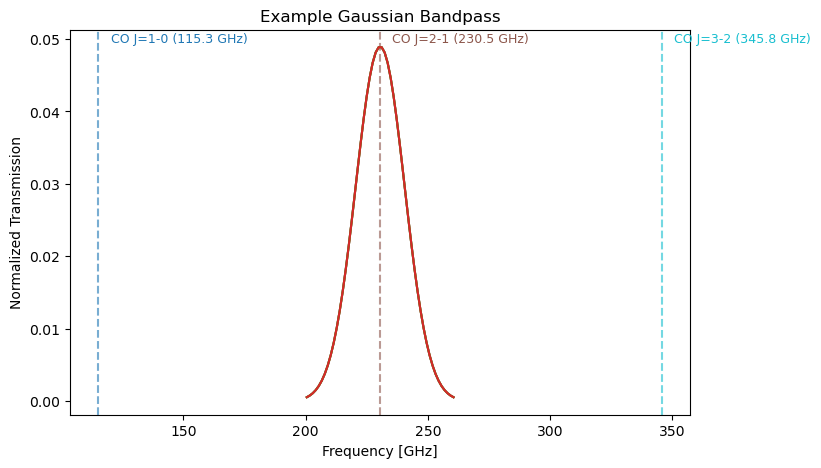

In [84]:
line = CO_LINES[1]
colors = plt.cm.tab10(np.linspace(0,1,len(CO_LINES)))
lazy_freqs, lazy_weights = make_bandpass(line*u.GHz, width=10*u.GHz, n_points=50)

make_co_plots(lazy_freqs, lazy_weights, colors=colors)
plt.plot(lazy_freqs.value, lazy_weights)
# plt.yscale('log')
plt.xlabel("Frequency [GHz]")
plt.ylabel("Normalized Transmission")
plt.title("Example Gaussian Bandpass")

In [21]:
start = time()
co_map = sky.get_emission(lazy_freqs,lazy_weights)
print(f"CO map making time: {time() - start:.2f}s")

CO map making time: 2.82s


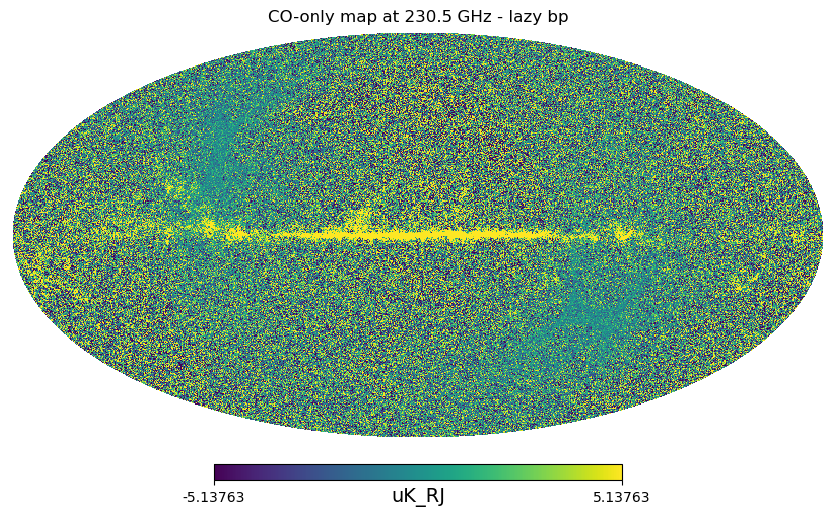

In [35]:
percentile = 90
v = np.percentile(co_map[0].value, percentile)
# co_map_out = hp.ud_grade(co_map[0].value, nside_out=NSIDE_OUT)
hp.mollview(co_map[0], title=f"CO-only map at {line} GHz - lazy bp", unit = co_map.unit, min=-v, max=v)

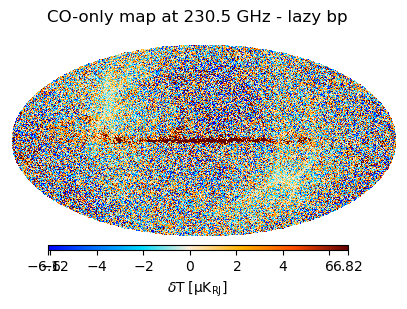

In [40]:
show_obs_logNxN(
    maps=[co_map[0]],
    labels=[""],
    min_val=None,
    max_val=None,
    n_cols=1,
    n_rows=1,
    dpi=100,        # make the figure high-res
    xsize=500,     # make mollview raster wider (more pixels)
    suptitle=f"CO-only map at {line} GHz - lazy bp"
)
# each map takes around 25s to render

### Using RIMO values at 100GHz

In [54]:
hdul_hfi.info()

Filename: /bigdata/aankit/rimo_files/HFI_RIMO_R3.00.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  HFI_RIMO      1 PrimaryHDU      14   ()      
  1  MAP_PARAMS    1 BinTableHDU     50   6R x 10C   [3A, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   
  2  BANDPASS_F100    1 BinTableHDU     28   12297R x 3C   ['1E', '1E', '1A']   
  3  BANDPASS_F100    1 BinTableHDU     28   12297R x 3C   [1E, 1E, 1A]   
  4  BANDPASS_F143    1 BinTableHDU     28   12602R x 3C   [1E, 1E, 1A]   
  5  BANDPASS_F217    1 BinTableHDU     28   12600R x 3C   [1E, 1E, 1A]   
  6  BANDPASS_F353    1 BinTableHDU     28   12930R x 3C   [1E, 1E, 1A]   
  7  BANDPASS_F545    1 BinTableHDU     28   13938R x 3C   ['1E', '1E', '1A']   
  8  BANDPASS_F857    1 BinTableHDU     28   16819R x 3C   ['1E', '1E', '1A']   
  9  BANDPASS_PSB353    1 BinTableHDU     28   12930R x 3C   [1E, 1E, 1A]   


Text(0.5, 1.0, 'Planck HFI Bandpasses (RIMO) @ 143 GHz')

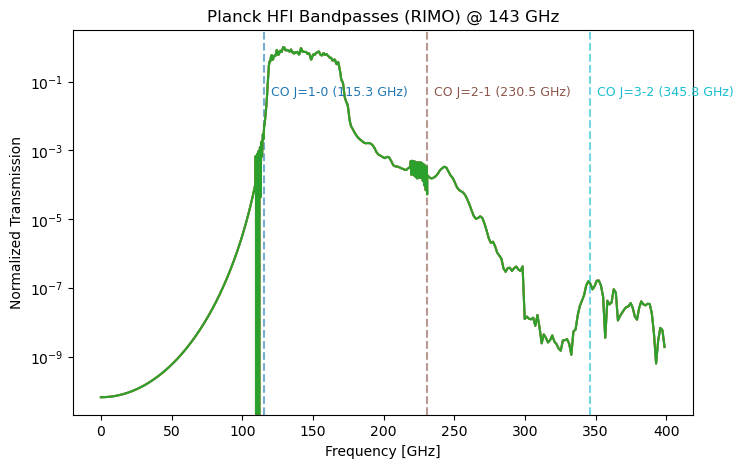

In [90]:
bandpass_hdu = hdul_hfi[4]  
wn = bandpass_hdu.data['WAVENUMBER'] * (1/u.cm)
freqs = wn.to(u.GHz, equivalencies=u.spectral())
weights = np.array(bandpass_hdu.data['TRANSMISSION'], dtype=np.float64)
# weights /= np.sum(weights) 
assert len(freqs) == len(weights)

make_co_plots(freqs[freqs.value<400], weights[freqs.value<400], colors=colors)
plt.yscale('log')
plt.xlabel("Frequency [GHz]")
plt.ylabel("Normalized Transmission")
plt.title(f"Planck HFI Bandpasses (RIMO) @ {bandpass_hdu.name[-3:]} GHz")

/bigdata/aankit/miniconda/envs/cmb-ml-py-312/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/bigdata/aankit/miniconda/envs/cmb-ml-py-312/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


CO map making time: 3.25s


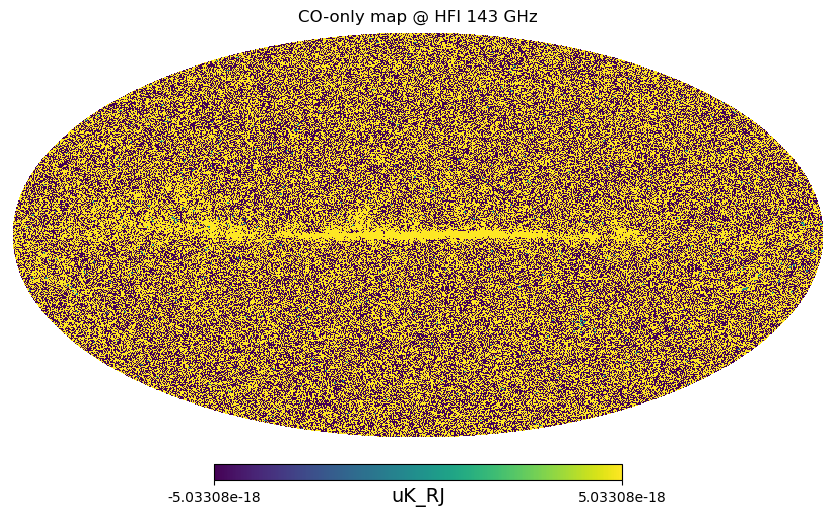

In [ ]:
percentile = 90
v = np.percentile(weights, percentile)

start= time()
co_map = sky.get_emission(freqs,weights)
# co_map_out = hp.ud_grade(co_map[0].value, nside_out=NSIDE_OUT)
hp.mollview(co_map[0], title=f"CO-only map @ HFI {bandpass_hdu.name[-3:]} GHz", min=-v, max=v, unit=co_map.unit)
print(f"CO map making time: {time() - start:.2f}s", )

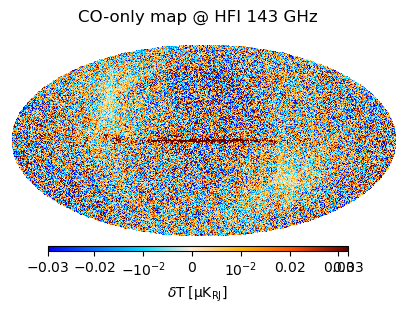

In [ ]:
show_obs_logNxN(
    maps=[co_map[0]],
    labels=[""],
    min_val=None,
    max_val=None,
    n_cols=1,
    n_rows=1,
    dpi=100,        
    xsize=500,     
    suptitle=f"CO-only map @ HFI {bandpass_hdu.name[-3:]} GHz"
)
# time to render ~15s per map

## d10 maps

- without BPO
- with lazy BP
- with full RIMO BP (>=100GHz)

In [95]:
PRESERT_STRINGS = ['d10']
NSIDE_SKY = 2048
NSIDE_OUT = 512
start = time()
sky = pysm3.Sky(nside=NSIDE_SKY, preset_strings=PRESERT_STRINGS, output_unit=pysm3.units.uK_RJ)
print(f"Sky (d10) generation time: {time() - start:.2f}s" )

Sky (d10) generation time: 2.12s


### Without BP

Map making time at 100 GHz: 9.93s
Map making time at 143 GHz: 10.09s
Map making time at 217 GHz: 9.78s
Map making time at 353 GHz: 2.07s
Map making time at 545 GHz: 9.99s
Map making time at 857 GHz: 10.13s


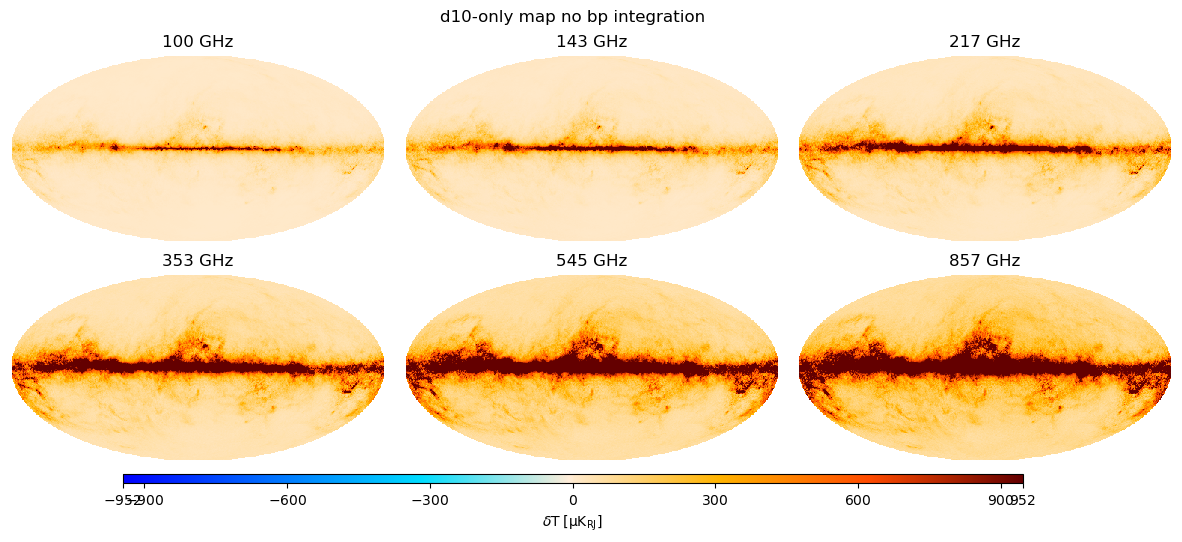

CPU times: user 7min 49s, sys: 2min 11s, total: 10min
Wall time: 2min 4s


In [103]:
%%time
freqs = [100, 143, 217, 353, 545, 857]

maps = []
labels = []


for freq in freqs:
    start = time()
    d10_map = sky.get_emission(freq*u.GHz)  
    maps.append(d10_map[0])
    labels.append(f"{freq} GHz")
    print(f"Map making time at {freq} GHz: {time() - start:.2f}s")
percentile = 90
v = np.percentile(d10_map[0].value, percentile)

show_obs_logNxN(
    maps=maps,
    labels=labels,
    min_val=-v,
    max_val=v,
    n_cols=3,
    n_rows=2,
    dpi=100,        
    xsize=500,     
    suptitle=f"d10-only map no bp integration"
)

### With lazy BP

In [ ]:
percentile = 90
maps = []
labels = []

for freq in freqs:
    lazy_freqs, lazy_weights = make_bandpass(freq*u.GHz, width=10*u.GHz, n_points=50)
    start = time()
    d10_map = sky.get_emission(lazy_freqs, lazy_weights)
    maps.append(d10_map[0])
    labels.append(f"{freq} GHz")
    print(f"Map making time at {freq} GHz: {time() - start:.2f}s")
    del d10_map  # free memory
print(f"Total time for all frequencies: {time() - start:.2f}s" )

#takes a LOOONGGGGG time

In [ ]:
v = np.percentile(d10_map.value, percentile)  # use last map for v
show_obs_logNxN(
    maps=maps,
    labels=labels,
    min_val=-v,
    max_val=v,
    n_cols=3,
    n_rows=2,
    dpi=100,        # make the figure high-res
    xsize=500,     # make mollview raster wider (more pixels)
    suptitle=f"d10-only map with lazy bp integration"
)

### With RIMO values

In [8]:
print(hdul_hfi.info())

Filename: /bigdata/aankit/rimo_files/HFI_RIMO_R3.00.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  HFI_RIMO      1 PrimaryHDU      14   ()      
  1  MAP_PARAMS    1 BinTableHDU     50   6R x 10C   [3A, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   
  2  BANDPASS_F100    1 BinTableHDU     28   12297R x 3C   ['1E', '1E', '1A']   
  3  BANDPASS_F100    1 BinTableHDU     28   12297R x 3C   [1E, 1E, 1A]   
  4  BANDPASS_F143    1 BinTableHDU     28   12602R x 3C   [1E, 1E, 1A]   
  5  BANDPASS_F217    1 BinTableHDU     28   12600R x 3C   [1E, 1E, 1A]   
  6  BANDPASS_F353    1 BinTableHDU     28   12930R x 3C   [1E, 1E, 1A]   
  7  BANDPASS_F545    1 BinTableHDU     28   13938R x 3C   ['1E', '1E', '1A']   
  8  BANDPASS_F857    1 BinTableHDU     28   16819R x 3C   ['1E', '1E', '1A']   
  9  BANDPASS_PSB353    1 BinTableHDU     28   12930R x 3C   [1E, 1E, 1A]   
None


In [9]:
bandpasses = [s.name for s in hdul_hfi][3:-1]
for bp in bandpasses:
    test_hdu = hdul_hfi[bp]
    freqs = test_hdu.data['WAVENUMBER'] * (1/u.cm).to(u.GHz, equivalencies=u.spectral())
    weights = test_hdu.data['TRANSMISSION'].astype(float)
    weights /= np.sum(weights)
    print(f"Length of freqs and weights for {bp}: {len(freqs)}, {len(weights)}")

Length of freqs and weights for BANDPASS_F100: 12297, 12297
Length of freqs and weights for BANDPASS_F143: 12602, 12602
Length of freqs and weights for BANDPASS_F217: 12600, 12600
Length of freqs and weights for BANDPASS_F353: 12930, 12930
Length of freqs and weights for BANDPASS_F545: 13938, 13938
Length of freqs and weights for BANDPASS_F857: 16819, 16819


Text(0, 0.5, 'Normalized Transmission')

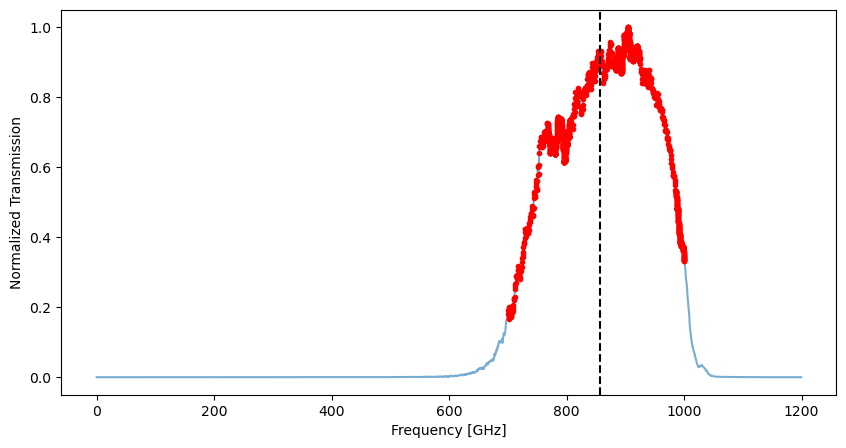

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u

# Select the HDU
hdu = hdul_hfi['BANDPASS_F857']

# Extract RIMO freqs and weights
freqs = hdu.data['WAVENUMBER'] * (1/u.cm).to(u.GHz, equivalencies=u.spectral())
weights = hdu.data['TRANSMISSION'].astype(float)

# Wide top-hat (700–1100 GHz)
mask_wide = (freqs.value >= 700) & (freqs.value <= 1000)
freqs_top_hat_wide = freqs[mask_wide]
# weights_top_hat_wide = np.ones_like(freqs_top_hat_wide.value)
# weights_top_hat_wide /= np.sum(weights_top_hat_wide)
weights_top_hat_wide = weights[mask_wide]

plt.figure(figsize=(10,5))
plt.plot(freqs[freqs.value<1200], weights[freqs.value<1200], label='Original RIMO bandpass', alpha=0.6)
plt.plot(freqs_top_hat_wide, weights_top_hat_wide, 'r.', markersize=6, label='Top-hat 700–1100 GHz')
plt.axvline(857, color='k', linestyle='--', label='Center 857 GHz')
plt.xlabel("Frequency [GHz]")
plt.ylabel("Normalized Transmission")

/bigdata/aankit/miniconda/envs/cmb-ml-py-312/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Map making time at BANDPASS_F857: 14424.55s


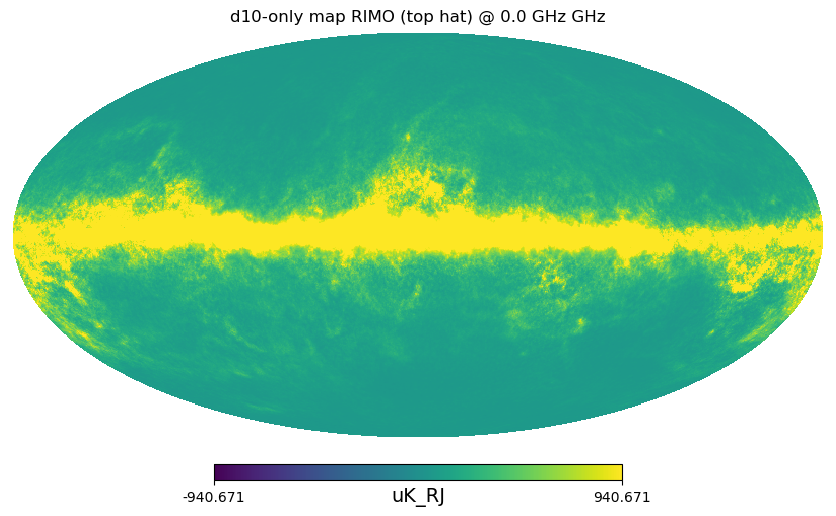

In [29]:
start = time()
d10_map = sky.get_emission(freqs_top_hat_wide,weights_top_hat_wide)


d10_map_out = hp.ud_grade(d10_map[0].value, nside_out=NSIDE_OUT)
v = np.percentile(d10_map_out, percentile)
hp.mollview(d10_map_out, title=f"d10-only map RIMO (top hat) @ {freq} GHz", unit = d10_map.unit , min=-v, max=v)

print(f"Map making time at {bp}: {time() - start:.2f}s")